In [1]:
!pip install facenet-pytorch==2.5.2 --no-deps -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.2 MB/s eta 0:00:00


In [2]:
import os
import cv2
import json
import random
import torch
from facenet_pytorch import MTCNN
from tqdm import tqdm
 
# --- CONFIG ---
CHUNK_DIRS = [
    '/kaggle/input/datasets/francisbawa/dfdc-train-sample',
    '/kaggle/input/datasets/francisbawa/dfdc-train/DFDC Train Part 00/dfdc_train_part_0',
    '/kaggle/input/datasets/francisbawa/dfdc-train/DFDC Train Part 01/dfdc_train_part_1',
    '/kaggle/input/datasets/francisbawa/dfdc-train/DFDC Train Part 02/dfdc_train_part_2',
    '/kaggle/input/datasets/francisbawa/dfdc-train/DFDC Train Part 03/dfdc_train_part_3',
    '/kaggle/input/datasets/francisbawa/dfdc-train/DFDC Train Part 04/dfdc_train_part_4',
    '/kaggle/input/datasets/francisbawa/dfdc-train/DFDC Train Part 05/dfdc_train_part_5',
]
 
OUTPUT_DIR = '/kaggle/working/face_dataset'
REAL_DIR = os.path.join(OUTPUT_DIR, 'real')
FAKE_DIR = os.path.join(OUTPUT_DIR, 'fake')
TARGET_PER_CLASS = 12500
FRAMES_PER_VIDEO = 10
 
os.makedirs(REAL_DIR, exist_ok=True)
os.makedirs(FAKE_DIR, exist_ok=True)
 
# --- INITIALIZE MTCNN ON GPU ---
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Running MTCNN Face Extractor on: {device}")
mtcnn = MTCNN(keep_all=False, select_largest=True, post_process=False, device=device)
 
def count_existing(directory):
    return len([f for f in os.listdir(directory) if f.endswith('.jpg')])
 
def process_video_mtcnn(video_filename, input_dir, label, frames_per_video=FRAMES_PER_VIDEO):
    video_path = os.path.join(input_dir, video_filename)
    cap = cv2.VideoCapture(video_path)
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        cap.release()
        return 0
    
    skip_frames = max(1, total_frames // frames_per_video)
    frame_count = 0
    saved_count = 0
    
    while cap.isOpened() and saved_count < frames_per_video:
        ret, frame = cap.read()
        if not ret: break
            
        if frame_count % skip_frames == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            boxes, _ = mtcnn.detect(frame_rgb)
            
            if boxes is not None:
                box = boxes[0]
                x1, y1, x2, y2 = [int(b) for b in box]
                
                ih, iw, _ = frame.shape
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(iw, x2), min(ih, y2)
                
                face_crop = frame[y1:y2, x1:x2]
                
                if face_crop.size != 0:
                    face_crop = cv2.resize(face_crop, (224, 224))
                    save_dir = REAL_DIR if label == 'REAL' else FAKE_DIR
                    # Prefix with chunk folder name to avoid filename collisions across chunks
                    chunk_prefix = os.path.basename(input_dir)
                    save_path = os.path.join(save_dir, f"{chunk_prefix}_{video_filename.split('.')[0]}_frame{frame_count}.jpg")
                    cv2.imwrite(save_path, face_crop)
                    saved_count += 1
                    
        frame_count += 1
    cap.release()
    return saved_count
 
# --- MULTI-CHUNK EXTRACTION ---
real_count = count_existing(REAL_DIR)
fake_count = count_existing(FAKE_DIR)
print(f"Already extracted: {real_count} real, {fake_count} fake. Target: {TARGET_PER_CLASS} each.\n")
 
for chunk_dir in CHUNK_DIRS:
    if real_count >= TARGET_PER_CLASS and fake_count >= TARGET_PER_CLASS:
        print("Target reached — stopping early.")
        break
 
    if not os.path.exists(chunk_dir):
        print(f"Skipping {chunk_dir} — not found (dataset not attached?)")
        continue
 
    metadata_path = os.path.join(chunk_dir, 'metadata.json')
    if not os.path.exists(metadata_path):
        print(f"Skipping {chunk_dir} — no metadata.json found.")
        continue
 
    with open(metadata_path) as f:
        metadata = json.load(f)
 
    videos = [f for f in os.listdir(chunk_dir) if f.endswith('.mp4')]
    random.shuffle(videos)  # shuffle so we don't always grab the same videos first
    print(f"Processing {os.path.basename(chunk_dir)}: {len(videos)} videos found...")
 
    for video in tqdm(videos, desc=os.path.basename(chunk_dir)):
        if real_count >= TARGET_PER_CLASS and fake_count >= TARGET_PER_CLASS:
            break
 
        if video not in metadata:
            continue
 
        label = metadata[video]['label']
 
        # Skip if we already have enough of this class
        if label == 'REAL' and real_count >= TARGET_PER_CLASS:
            continue
        if label == 'FAKE' and fake_count >= TARGET_PER_CLASS:
            continue
 
        n = process_video_mtcnn(video, chunk_dir, label)
 
        if label == 'REAL':
            real_count += n
        else:
            fake_count += n
 
    print(f"After {os.path.basename(chunk_dir)}: {real_count} real | {fake_count} fake\n")
 
print(f"Extraction complete! Final: {real_count} real faces, {fake_count} fake faces.")
print(f"Check {OUTPUT_DIR}")

Running MTCNN Face Extractor on: cuda:0
Already extracted: 0 real, 0 fake. Target: 12500 each.

Processing dfdc-train-sample: 400 videos found...


dfdc-train-sample: 100%|██████████| 400/400 [15:30<00:00,  2.33s/it]


After dfdc-train-sample: 760 real | 3102 fake

Processing dfdc_train_part_0: 1334 videos found...


dfdc_train_part_0: 100%|██████████| 1334/1334 [43:21<00:00,  1.95s/it]


After dfdc_train_part_0: 1616 real | 12508 fake

Processing dfdc_train_part_1: 1699 videos found...


...

After dfdc_train_part_3: 7171 real | 12508 fake

Processing dfdc_train_part_4: 1701 videos found...


dfdc_train_part_4: 100%|██████████| 1701/1701 [08:40<00:00,  3.27it/s]


After dfdc_train_part_4: 8992 real | 12508 fake

Processing dfdc_train_part_5: 2483 videos found...


dfdc_train_part_5:  98%|█████████▊| 2437/2483 [15:21<00:17,  2.64it/s]

After dfdc_train_part_5: 12505 real | 12508 fake

Extraction complete! Final: 12505 real faces, 12508 fake faces.
Check /kaggle/working/face_dataset


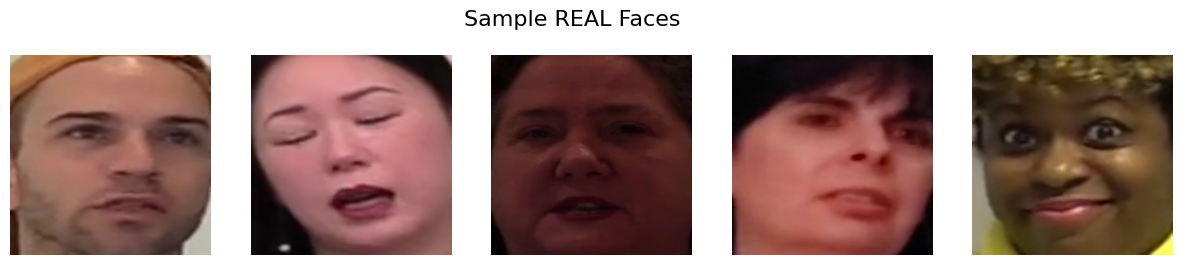

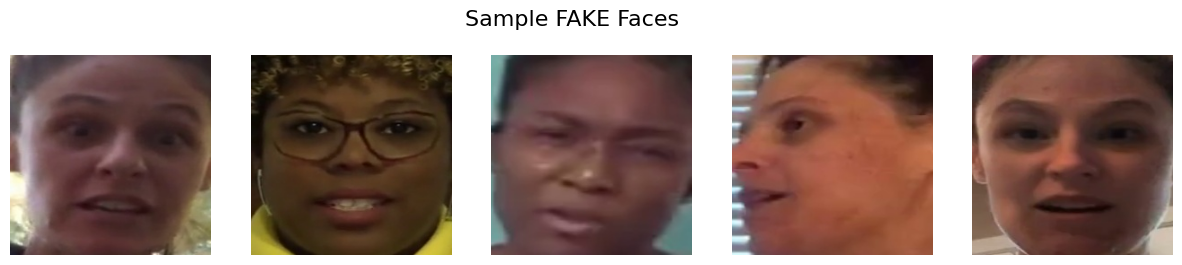

In [3]:
import matplotlib.pyplot as plt
import glob
import random
import cv2

def show_random_faces(folder_path, title):
    # Grab all current images in the folder
    images = glob.glob(f"{folder_path}/*.jpg")
    
    if len(images) < 5:
        print(f"Waiting for more images in {title} folder...")
        return
        
    # Pick 5 random faces
    sample_images = random.sample(images, 5)
    
    # Plot them in a row
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(title, fontsize=16)
    
    for i, img_path in enumerate(sample_images):
        # OpenCV reads as BGR, matplotlib expects RGB
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].axis('off')
        
    plt.show()

# Show 5 REAL and 5 FAKE faces
show_random_faces('/kaggle/working/face_dataset/real', 'Sample REAL Faces')
show_random_faces('/kaggle/working/face_dataset/fake', 'Sample FAKE Faces')